<a href="https://colab.research.google.com/github/mkg6573/Social_media_impact_on_life_ML_/blob/main/Algorithm_Comparison/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Train Test Split
from sklearn.model_selection import train_test_split

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

# Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

##Load Dataset

In [6]:

df = pd.read_csv("/content/Cleaned_Social_media_impact_on_life_Clean_Dataset.csv")


df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [7]:
print("Shape of Dataset : ", df.shape)

Shape of Dataset :  (1705, 9)


In [8]:
print("\nColumns in Dataset : \n")
print(df.columns)


Columns in Dataset : 

Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')


In [9]:
print("\nDataset Information : \n")
print(df.info())


Dataset Information : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           1705 non-null   int64  
 1   Gender                        1705 non-null   object 
 2   Academic_Level                1705 non-null   object 
 3   Avg_Daily_Usage_Hours         1705 non-null   float64
 4   Most_Used_Platform            1705 non-null   object 
 5   Affects_Academic_Performance  1705 non-null   object 
 6   Sleep_Hours_Per_Night         1705 non-null   float64
 7   Mental_Health_Score           1705 non-null   float64
 8   Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 120.0+ KB
None


In [10]:
print("\nMissing Values : \n")
print(df.isnull().sum())


Missing Values : 

Age                             0
Gender                          0
Academic_Level                  0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64


##LABEL ENCODING

In [11]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

# Display Encoded Dataset
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,1,2,4.0,0,0,6.7,6.8,1
1,23,0,2,1.6,4,0,8.6,7.6,2
2,22,1,0,4.6,1,0,6.7,7.0,1
3,18,1,2,7.0,5,1,5.4,5.3,0
4,24,0,1,7.5,0,1,5.0,4.4,0


##Feature Selection

In [73]:
X = df.drop("Overall_Impact", axis=1)

y = df["Overall_Impact"]

X = df.drop(
    ["Overall_Impact", "Mental_Health_Score"],
    axis=1
)

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Features Shape : ", X.shape)

print("Target Shape : ", y.shape)

Features Shape :  (1705, 7)
Target Shape :  (1705,)


In [74]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size = 0.2,

    random_state = 42
)

print("Training Data Shape : ", X_train.shape)

print("Testing Data Shape : ", X_test.shape)

Training Data Shape :  (1364, 7)
Testing Data Shape :  (341, 7)


#LOGISTIC REGRESSION

In [75]:
lr_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', LogisticRegression())
])

In [76]:
# Creating Model
lr = LogisticRegression()

# Training Model
lr_pipeline.fit(X_train, y_train)

# Prediction
lr_pred = lr_pipeline.predict(X_test)

# Accuracy Score
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy : ", lr_acc)

Logistic Regression Accuracy :  0.8621700879765396


###CONFUSION MATRIX

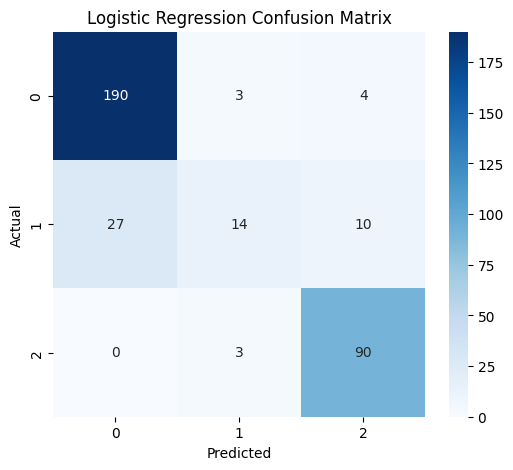

In [77]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [78]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       197
           1       0.70      0.27      0.39        51
           2       0.87      0.97      0.91        93

    accuracy                           0.86       341
   macro avg       0.81      0.74      0.74       341
weighted avg       0.85      0.86      0.84       341



#DECISION TREE CLASSIFIER

In [79]:
dt_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', DecisionTreeClassifier())
])

In [80]:
dt = DecisionTreeClassifier()

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy : ", dt_acc)

Decision Tree Accuracy :  0.9149560117302052


###CONFUSION MATRIX

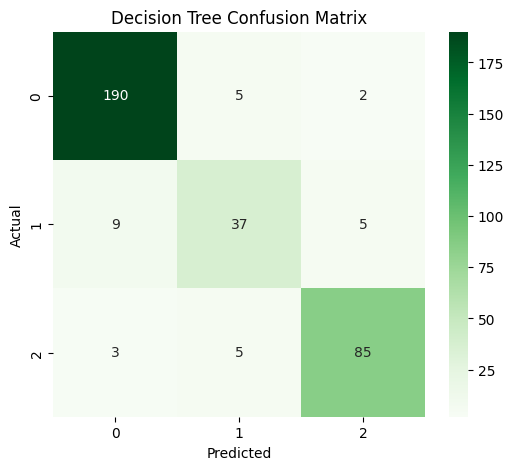

In [81]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [82]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       197
           1       0.79      0.73      0.76        51
           2       0.92      0.91      0.92        93

    accuracy                           0.91       341
   macro avg       0.88      0.87      0.88       341
weighted avg       0.91      0.91      0.91       341



# RANDOM FOREST CLASSIFIER

In [83]:
rf_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', RandomForestClassifier())
])

In [84]:
rf = RandomForestClassifier()

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy : ", rf_acc)

Random Forest Accuracy :  0.9618768328445748


###CONFUSION MATRIX

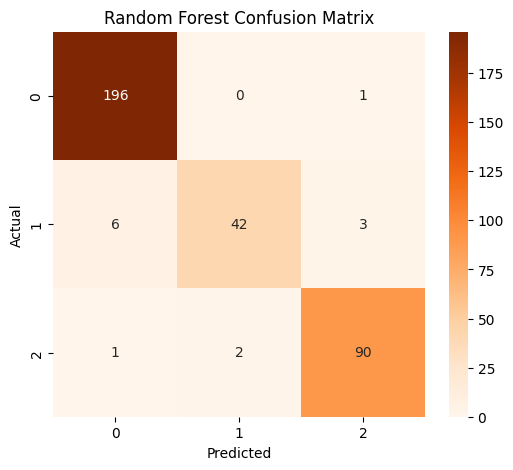

In [85]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [86]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       197
           1       0.95      0.82      0.88        51
           2       0.96      0.97      0.96        93

    accuracy                           0.96       341
   macro avg       0.96      0.93      0.94       341
weighted avg       0.96      0.96      0.96       341



###FEATURE IMPORTANCE

In [89]:
importance = rf_pipeline.named_steps['model'].feature_importances_

features = X.columns

feature_df = pd.DataFrame({

    'Feature' : features,

    'Importance' : importance
})

feature_df = feature_df.sort_values(

    by='Importance',

    ascending=False
)

feature_df

,Feature,Importance
6,Sleep_Hours_Per_Night,0.335921
3,Avg_Daily_Usage_Hours,0.312593
5,Affects_Academic_Performance,0.164196
4,Most_Used_Platform,0.076881
0,Age,0.056547
2,Academic_Level,0.036854
1,Gender,0.017009


###Feature Importance Graph

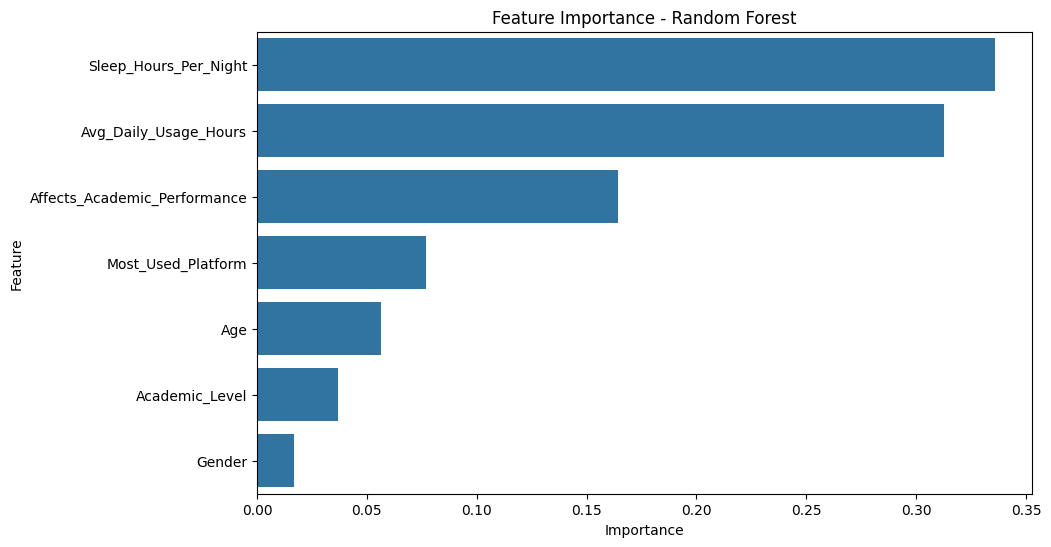

In [90]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance - Random Forest")

plt.show()

#KNN (K NEAREST NEIGHBOR)

In [91]:
knn_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', KNeighborsClassifier())
])

In [92]:
knn = KNeighborsClassifier()

knn_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy : ", knn_acc)

KNN Accuracy :  0.9120234604105572


###CONFUSION MATRIX

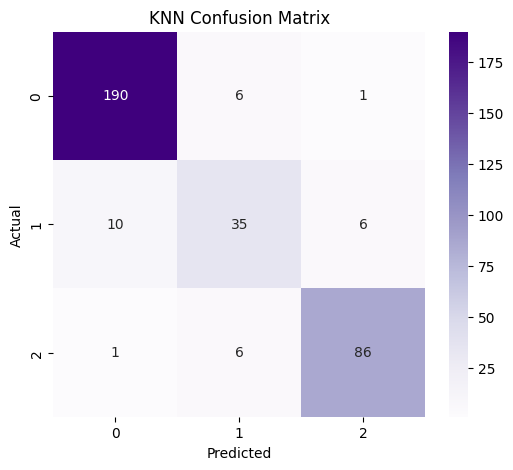

In [93]:
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [94]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       197
           1       0.74      0.69      0.71        51
           2       0.92      0.92      0.92        93

    accuracy                           0.91       341
   macro avg       0.87      0.86      0.86       341
weighted avg       0.91      0.91      0.91       341



#NAIVE BAYES

In [95]:
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

In [96]:
nb = GaussianNB()

nb_pipeline.fit(X_train, y_train)

nb_pred = nb_pipeline.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy : ", nb_acc)

Naive Bayes Accuracy :  0.8357771260997068


###CONFUSION MATRIX

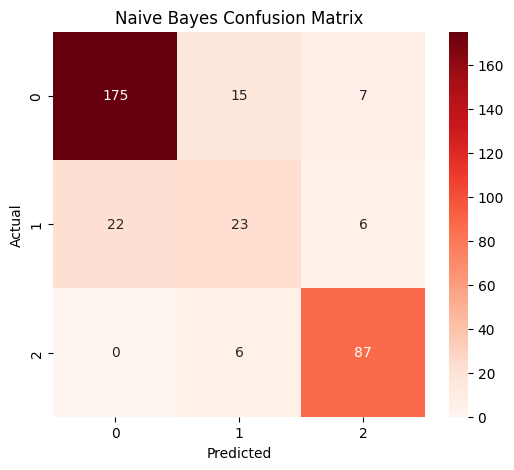

In [97]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [98]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       197
           1       0.52      0.45      0.48        51
           2       0.87      0.94      0.90        93

    accuracy                           0.84       341
   macro avg       0.76      0.76      0.76       341
weighted avg       0.83      0.84      0.83       341



#SVM (SUPPORT VECTOR )

In [99]:
svm_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', SVC())
])

In [100]:
svm = SVC()

svm_pipeline.fit(X_train, y_train)

svm_pred = svm_pipeline.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy : ", svm_acc)

SVM Accuracy :  0.9237536656891495


###CONFUSION MATRIX

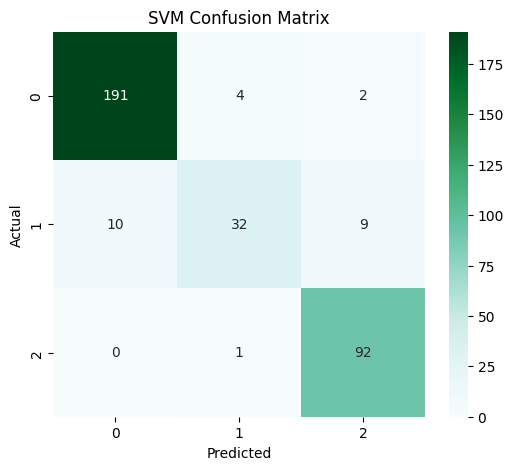

In [101]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='BuGn'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [102]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       197
           1       0.86      0.63      0.73        51
           2       0.89      0.99      0.94        93

    accuracy                           0.92       341
   macro avg       0.90      0.86      0.88       341
weighted avg       0.92      0.92      0.92       341



#XGBOOST

In [103]:
xgb_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', XGBClassifier())
])

In [104]:
xgb = XGBClassifier()

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy : ", xgb_acc)

XGBoost Accuracy :  0.9589442815249267


###CONFUSION MATRIX

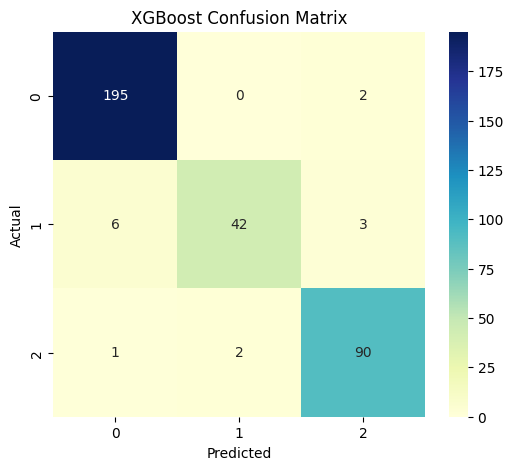

In [105]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [106]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       197
           1       0.95      0.82      0.88        51
           2       0.95      0.97      0.96        93

    accuracy                           0.96       341
   macro avg       0.96      0.93      0.94       341
weighted avg       0.96      0.96      0.96       341



###MODEL COMPARISON

In [107]:
results = pd.DataFrame({

    'Model' : [

        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Naive Bayes',
        'SVM',
        'XGBoost'
    ],

    'Accuracy' : [

        lr_acc,
        dt_acc,
        rf_acc,
        knn_acc,
        nb_acc,
        svm_acc,
        xgb_acc
    ]
})

results = results.sort_values(

    by='Accuracy',

    ascending=False
)

results

,Model,Accuracy
2,Random Forest,0.961877
6,XGBoost,0.958944
5,SVM,0.923754
1,Decision Tree,0.914956
3,KNN,0.912023
0,Logistic Regression,0.862170
4,Naive Bayes,0.835777


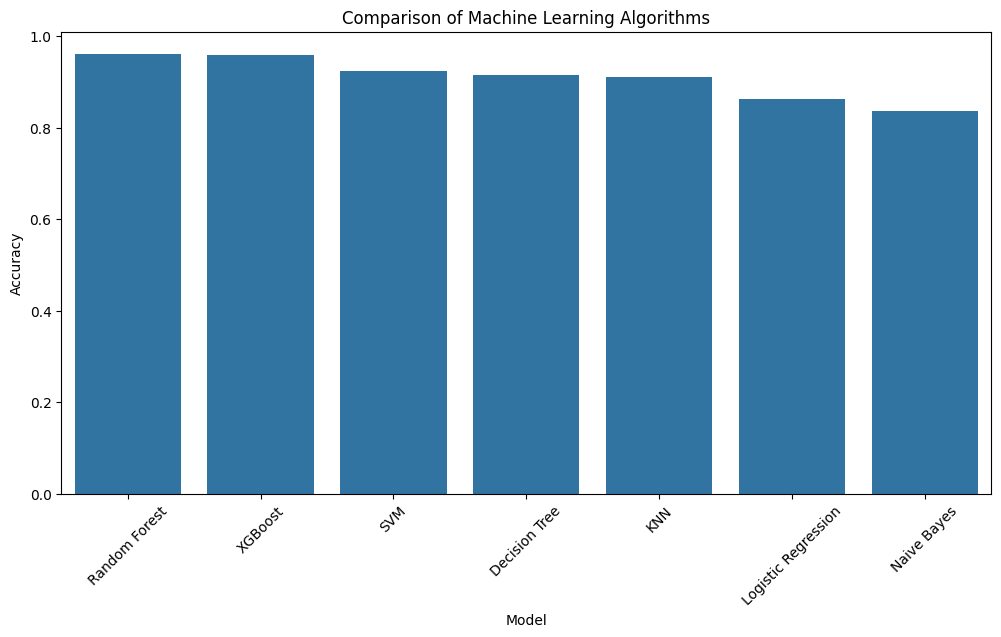

In [108]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Comparison of Machine Learning Algorithms")

plt.xticks(rotation=45)

plt.show()

###BEST MODEL

In [109]:
best_model = results.iloc[0]

print("Best Model : ", best_model['Model'])

print("Best Accuracy : ", best_model['Accuracy'])

Best Model :  Random Forest
Best Accuracy :  0.9618768328445748


In [110]:
import pickle

pickle.dump(
    rf_pipeline,
    open("best_pipeline.pkl", "wb")
)

In [113]:
user_input = [[

    21,     # Age
    1,      # Gender
    0,
    6.5,    # Avg Daily Usage Hours
    1,
    0,
    7,      # Sleep Hours Per Night


    # Add ALL remaining feature values
]]

In [114]:
model = pickle.load(
    open("best_pipeline.pkl", "rb")
)
prediction = model.predict(user_input)

print(prediction)

[1]
